In [ ]:
!pip install shap

**TRAINING DATA**

Data yang telah didapatkan akan dilakukan training dan tuning terlebih dahulu untuk mengetahui bagaimana data dan potensi dari prediksi. Data dimasukan terlebih dahulu untuk dilakukan pembacaan.

**1.INPUT PEMBACAAN DATA**

In [2]:
from google.colab import files
import io
import pandas as pd

print("Silakan unggah file PKL 2607.xlsx:")
uploaded = files.upload()

# Membaca data ke dalam DataFrame Pandas
file_name = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[file_name]), sheet_name="PKL 2607")

# Membersihkan kolom 'Unnamed' bawaan sistem log
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
print("\nData berhasil dimuat! Ukuran data:", df.shape)

Silakan unggah file PKL 2607.xlsx:


Saving PKL 2607.xlsx to PKL 2607.xlsx

Data berhasil dimuat! Ukuran data: (14400, 18)


**2. PERHITUNGAN ECF PADA DATA SERTA LABELING**

Data yang telah dibaca akan dilakukan perhitungan dengan menggunakan rumus perpindahan panas pada bagian PSH, SSH, dan RH. Perhitungan dilakukan terhadap numerik ECF kemudian di klasifikasikan menjadi 4 kategori data yang akan diklasifikasikan.

In [3]:
import pandas as pd
import numpy as np
from google.colab import files

# Perhitungan Delta Temperatur berdasarkan perumusan yang terdapat dalam Laporan Akhir
# Reheater (RH)
df['Delta_T_RH'] = (df['06SB__TE000X-X - RH OUT TEMP SEL XMTR [C]']- df['06SB__TE0073-X - RH INL TEMP S A SEL XMTR [C]'])

# Primary Superheater (PSH)
df['Delta_T_PSH'] = (df['06AE__TE040800 - PSH 2 STM TEMP [DEG C]']- df['06AE__TE0401-X - PSH II INL TEMP S A SEL XMTR [C]'])

# Secondary Superheater
df['Delta_T_SSH'] = (df['06SB__TE0171-X - MS TEMP SEL XMTR [C]']- df['06AE__TE0409-X - SSH INL TEMP S A SEL [C]'])

# Indikator Penyerapan Panas
steam_flow = '06SB__FT000X-X - MAIN STEAM FLOW [t/h]'
df['Q_PSH'] = df[steam_flow] * df['Delta_T_PSH']
df['Q_SSH'] = df[steam_flow] * df['Delta_T_SSH']
df['Q_RH']  = df[steam_flow] * df['Delta_T_RH']


# CLEAN CONDITION (95th Percentile)
Qclean_PSH = df['Q_PSH'].quantile(0.95)
Qclean_SSH = df['Q_SSH'].quantile(0.95)
Qclean_RH  = df['Q_RH'].quantile(0.95)


# ESTIMATED CLEANLINESS FACTOR
df['ECF_PSH'] = df['Q_PSH'] / Qclean_PSH
df['ECF_SSH'] = df['Q_SSH'] / Qclean_SSH
df['ECF_RH']  = df['Q_RH']  / Qclean_RH

# Batasi maksimum = 1
df['ECF_PSH'] = df['ECF_PSH'].clip(upper=1)
df['ECF_SSH'] = df['ECF_SSH'].clip(upper=1)
df['ECF_RH']  = df['ECF_RH'].clip(upper=1)


# MENENTUKAN LOKASI FOULING
section = ['ECF_PSH','ECF_SSH','ECF_RH']

df['Lokasi_Fouling'] = (df[section].idxmin(axis=1).replace({
        'ECF_PSH':'Primary Superheater',
        'ECF_SSH':'Secondary Superheater',
        'ECF_RH':'Reheater'
    }))

# MENENTUKAN TINGKAT FOULING
def kategori(ecf):
    if ecf >= 0.90:
        return 'Clean'
    elif ecf >= 0.80:
        return 'Light Fouling'
    elif ecf >= 0.70:
        return 'Moderate Fouling'
    else:
        return 'Heavy Fouling'

df['Kategori_PSH'] = df['ECF_PSH'].apply(kategori)
df['Kategori_SSH'] = df['ECF_SSH'].apply(kategori)
df['Kategori_RH']  = df['ECF_RH'].apply(kategori)

# PREVIEW
print("Preview Estimated Cleanliness Factor")

display(df[
      [
        'Time',
        'ECF_PSH',
        'ECF_SSH',
        'ECF_RH',
        'Lokasi_Fouling',
        'Kategori_PSH',
        'Kategori_SSH',
        'Kategori_RH'
        ]].head())

# EXPORT
nama_file_output = 'Hasil_ECF_Boiler.xlsx'
df.to_excel(
    nama_file_output,
    index=False
)
files.download(nama_file_output)
print("Perhitungan Estimated Cleaness Factor Selesai.")

Preview Estimated Cleanliness Factor


,Time,ECF_PSH,ECF_SSH,ECF_RH,Lokasi_Fouling,Kategori_PSH,Kategori_SSH,Kategori_RH
0,2026-07-12 00:00:00,0.859429,0.788124,0.800677,Secondary Superheater,Light Fouling,Moderate Fouling,Light Fouling
1,2026-07-12 00:01:00,0.797334,0.756420,0.758964,Secondary Superheater,Moderate Fouling,Moderate Fouling,Moderate Fouling
2,2026-07-12 00:02:00,0.777408,0.740059,0.732566,Reheater,Moderate Fouling,Moderate Fouling,Moderate Fouling
3,2026-07-12 00:03:00,0.803829,0.756199,0.728423,Reheater,Light Fouling,Moderate Fouling,Moderate Fouling
4,2026-07-12 00:04:00,0.820324,0.746038,0.706704,Reheater,Light Fouling,Moderate Fouling,Moderate Fouling


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Perhitungan Estimated Cleaness Factor Selesai.


**3. Training Data**

Data di proses dengan menggunakan *artificial neural network* (ANN) untuk melakukan proses prediksi. Dengan menggunakan tuning hidden layer. Hasil training tersebut akan menunjukan akurasi dari algoritma yang telah diberikan.

Melatih ANN...
HASIL EVALUASI

ECF_PSH
MAE : 0.0749
R²  : 0.6396

ECF_SSH
MAE : 0.0299
R²  : 0.9199

ECF_RH
MAE : 0.0442
R²  : 0.8238




,Target,MAE,R2
0,ECF_PSH,0.074927,0.639556
1,ECF_SSH,0.029851,0.919947
2,ECF_RH,0.044228,0.823823


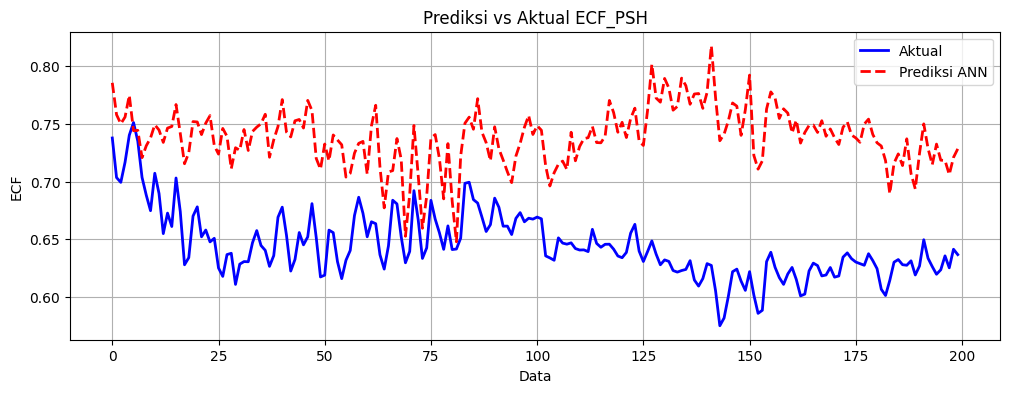

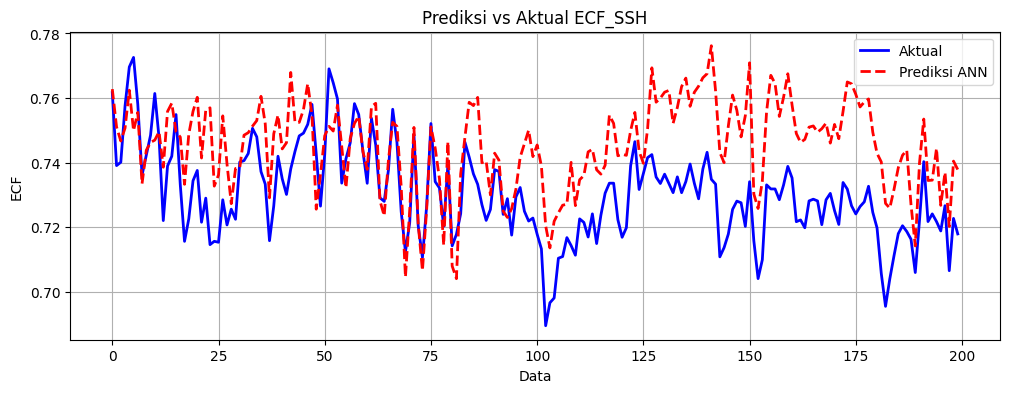

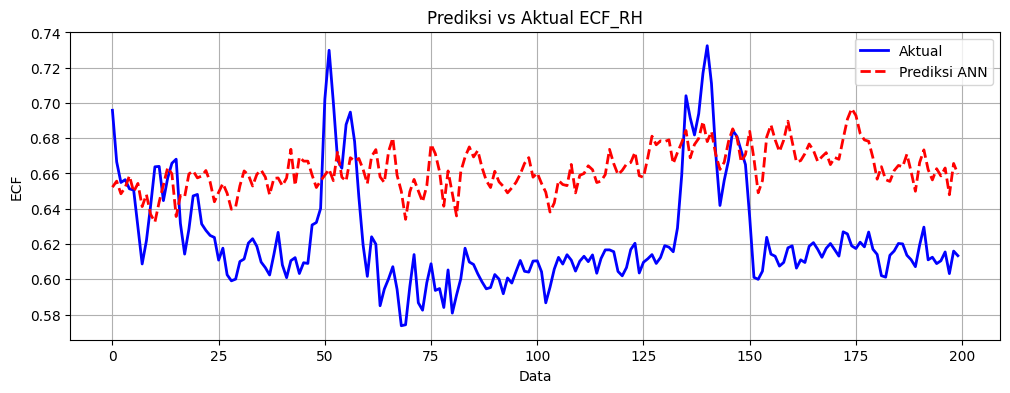

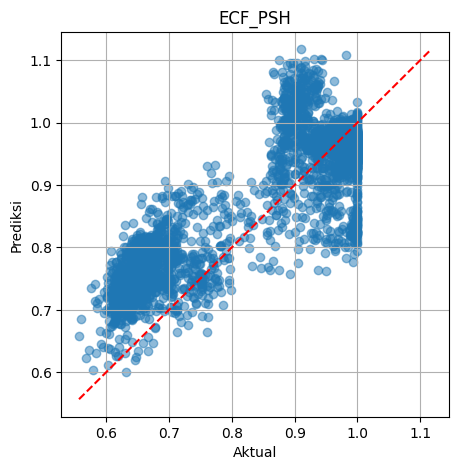

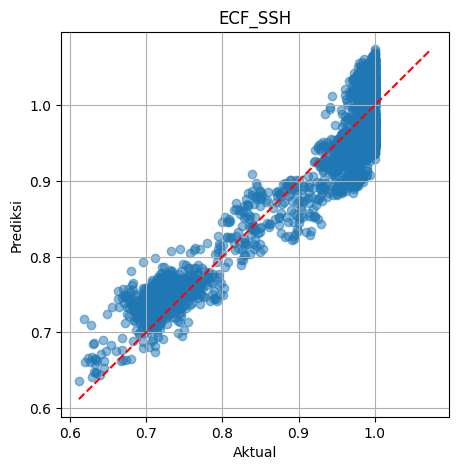

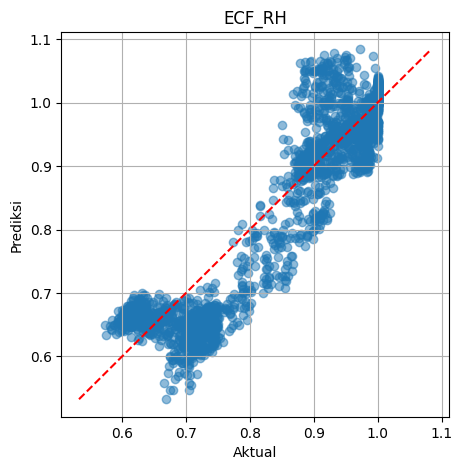

RATA-RATA DATA UJI
           ECF_PSH      ECF_SSH       ECF_RH
count  2880.000000  2880.000000  2880.000000
mean      0.837283     0.880034     0.856890
std       0.149268     0.125181     0.136614
min       0.556656     0.611834     0.573644
25%       0.670054     0.734157     0.722278
50%       0.898074     0.961699     0.907187
75%       0.983452     0.990941     0.985463
max       1.000000     1.000000     1.000000
RATA-RATA HASIL PREDIKSI
           ECF_PSH      ECF_SSH       ECF_RH
count  2880.000000  2880.000000  2880.000000
mean      0.871500     0.881405     0.844722
std       0.110214     0.113820     0.159617
min       0.600257     0.635766     0.532661
25%       0.765728     0.756412     0.662285
50%       0.897725     0.927601     0.912804
75%       0.963706     0.969321     0.995413
max       1.117616     1.073926     1.084000


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# INPUT DAN TARGET
# Menambahkan fitur untuk melihat korelasi antar parameter perhitungan akhir yang telah dilakukan, Target akhir dari penggunaan algoritma
features = [
    '06IO00C00062-A - COAL FUEL SUPPLY RATE [t/h]',
    '06DP6101M103-A - B TOTAL COMPT AIR FLOW [t/h]',
    '06GG__AT001A00 - FURN OUT A FG O2 [%]',
    '06SB__PT0000-X - MAIN STM PRESS MED SEL XMTR [kg/cm2]',
    '06SJ__FT006A-X - ECON INL FW FLOW AVG SEL XMTR [t/h]',
    '36EL__JT000G-B - UNIT MASTER GENERATED MW []']
targets = [
    'ECF_PSH',
    'ECF_SSH',
    'ECF_RH']

# Data Cleaning
df_clean = df.dropna(subset=features + targets).copy()
X = df_clean[features]
y = df_clean[targets]

# Training Data Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False,
    random_state=42
)

# Normalisasi Data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model ANN yang digunaan
print("Melatih ANN...")
model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=3000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)
model.fit(X_train, y_train)

# Model Prediksi
y_pred = model.predict(X_test)

y_pred = pd.DataFrame(
    y_pred,
    columns=targets,
    index=y_test.index
)

# Evaluasi data
print("="*60)
print("HASIL EVALUASI")
print("="*60)

hasil = []

for col in targets:

    mae = mean_absolute_error(
        y_test[col],
        y_pred[col]
    )

    r2 = r2_score(
        y_test[col],
        y_pred[col]
    )

    hasil.append([col,mae,r2])
    print(f"\n{col}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")

hasil = pd.DataFrame(
    hasil,
    columns=[
        "Target",
        "MAE",
        "R2"
        ])
print("\n")
display(hasil)

#Grafik Perbandingan Hasil Prediksi dengan Aktual
for col in targets:
    plt.figure(figsize=(12,4))
    plt.plot(
        y_test[col].iloc[:200].values,
        color='blue',
        linewidth=2,
        label='Aktual')
    plt.plot(
        y_pred[col].iloc[:200].values,
        '--',
        color='red',
        linewidth=2,
        label='Prediksi ANN')
    plt.title(f"Prediksi vs Aktual {col}")
    plt.xlabel("Data")
    plt.ylabel("ECF")
    plt.grid(True)
    plt.legend()
    plt.show()

#Scatter Plot
for col in targets:
    plt.figure(figsize=(5,5))
    plt.scatter(
        y_test[col],
        y_pred[col],
        alpha=0.5)
    xmin = min(
        y_test[col].min(),
        y_pred[col].min())
    xmax = max(
        y_test[col].max(),
        y_pred[col].max())
    plt.plot(
        [xmin,xmax],
        [xmin,xmax],
        'r--')
    plt.xlabel("Aktual")
    plt.ylabel("Prediksi")
    plt.title(col)
    plt.grid(True)
    plt.show()

# Deskripsi numerik hasil data yang telah dilakukan pengujian atau data aktual
print("RATA-RATA DATA UJI")

# Deskripsi hasil data yang telah dilakukan pelatihan untuk data prediksi
print(y_test.describe())
print("RATA-RATA HASIL PREDIKSI")
print(y_pred.describe())

4. **Loss Training**

Perhitungan untuk loss hasil dari training data

Jumlah iterasi : 245
Final loss     : 0.0005492934947604325


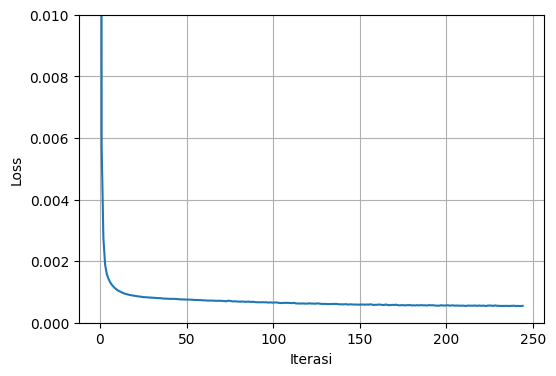

In [5]:
plt.figure(figsize=(6,4))
plt.plot(model.loss_curve_)
plt.ylim(0, 0.01)
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.grid(True)

print("Jumlah iterasi :", model.n_iter_)
print("Final loss     :", model.loss_)

 **6. Perhitungan Parametrik Hasil Training**

Perhitungan parameterik hasil training digunakan untuk mencari nilai paramterik hasil dari training. Angka yang akan dihasilkan akan menggunakan parameter R\^2, RMSE, MAE

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

hasil_data = [] # Changed variable name to avoid conflict and initialized as a list

for col in targets:

    mae = mean_absolute_error(
        y_test[col],
        y_pred[col]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test[col],
            y_pred[col]
        )
    )

    r2 = r2_score(
        y_test[col],
        y_pred[col]
    )

    hasil_data.append([col, mae, rmse, r2]) # Append to the list

    print(f"\n{col}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

# Create the DataFrame outside the loop
hasil = pd.DataFrame(
    hasil_data, # Use the collected list
    columns=[
        "Target",
        "MAE",
        "RMSE",
        "R2"
    ]
)

display(hasil)


ECF_PSH
MAE  : 0.0749
RMSE : 0.0896
R²   : 0.6396

ECF_SSH
MAE  : 0.0299
RMSE : 0.0354
R²   : 0.9199

ECF_RH
MAE  : 0.0442
RMSE : 0.0573
R²   : 0.8238


,Target,MAE,RMSE,R2
0,ECF_PSH,0.074927,0.089601,0.639556
1,ECF_SSH,0.029851,0.035412,0.919947
2,ECF_RH,0.044228,0.057332,0.823823


**7. PERHITUNGAN CORRELATION MATRIX**

Perhitungan dilakukan untuk menghitung korelasi setiap variabel yang digunakan dalam perhitungan, sehingga dapat mendukung data hasil operasi yang akan di prediksi.

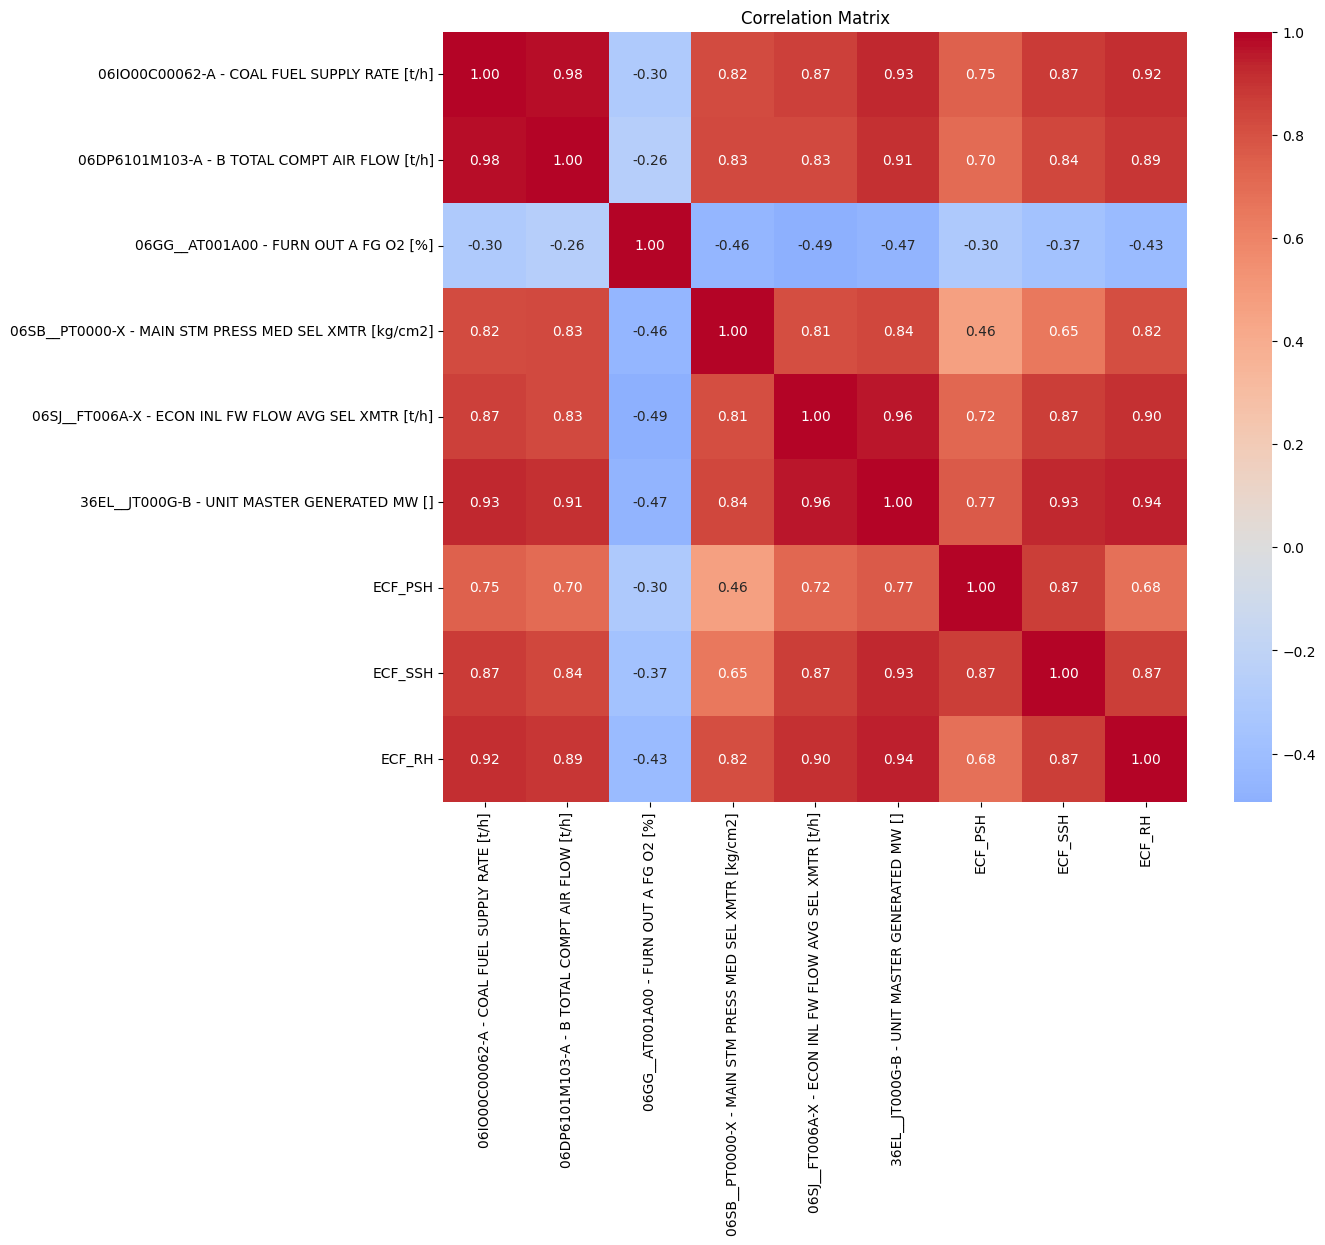

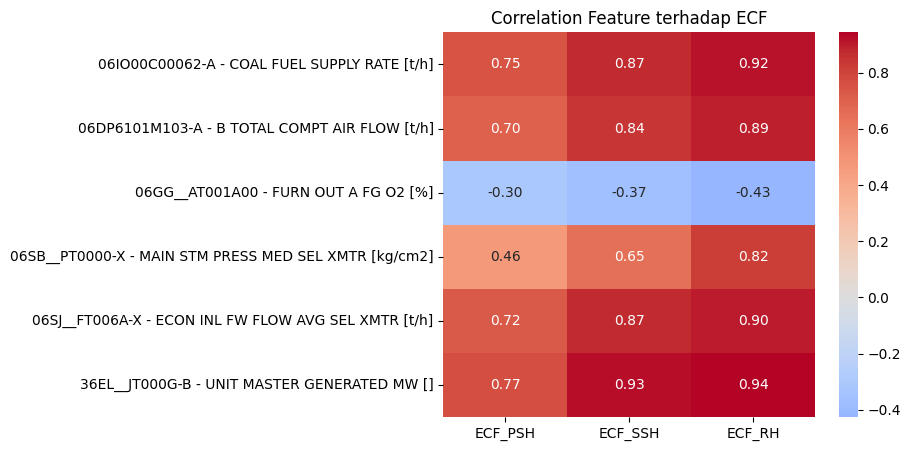

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Feature dan Target
features = [
    '06IO00C00062-A - COAL FUEL SUPPLY RATE [t/h]',
    '06DP6101M103-A - B TOTAL COMPT AIR FLOW [t/h]',
    '06GG__AT001A00 - FURN OUT A FG O2 [%]',
    '06SB__PT0000-X - MAIN STM PRESS MED SEL XMTR [kg/cm2]',
    '06SJ__FT006A-X - ECON INL FW FLOW AVG SEL XMTR [t/h]',
    '36EL__JT000G-B - UNIT MASTER GENERATED MW []'
]
targets = [
    'ECF_PSH',
    'ECF_SSH',
    'ECF_RH'
]

# Correlation Matrix
corr = df[features + targets].corr(method='pearson')

# Heatmap seluruh variabel
plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

# Heatmap Feature vs Target
corr_target = corr.loc[features, targets]
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)
plt.title('Correlation Feature terhadap ECF')
plt.show()

**8. SHAP**

SHAP digunakan untuk melihat variabel parameter yang paling berpengaruh dalam perhitungan.

Menghitung SHAP...


  0%|          | 0/100 [00:00<?, ?it/s]

<class 'numpy.ndarray'>
(100, 6, 3)
SHAP SUMMARY - ECF_PSH


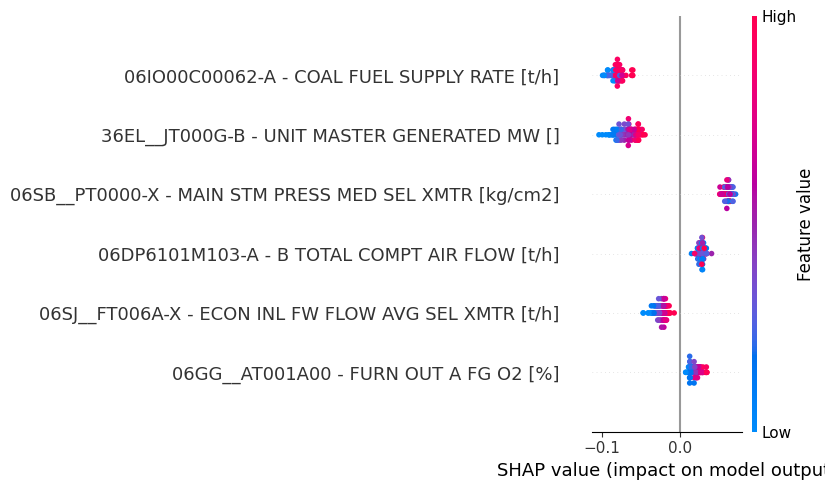

In [9]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_train_df = pd.DataFrame(
    X_train,
    columns=features
)

X_test_df = pd.DataFrame(
    X_test,
    columns=features
)

X_background = shap.sample(
    X_train_df,
    100,
    random_state=42
)

explainer = shap.KernelExplainer(
    model.predict,
    X_background
)

print("Menghitung SHAP...")
shap_values = explainer.shap_values(
    X_test_df.iloc[:100]
)

print(type(shap_values))
print(np.array(shap_values).shape)
print("SHAP SUMMARY - ECF_PSH")

shap.summary_plot(

    shap_values[:,:,0],
    X_test_df.iloc[:100],
    feature_names=features,
    max_display=6,
    plot_size=(8,5)
)

**9. PERHITUNGAN RESIDUAL**

        ECF_PSH   ECF_SSH    ECF_RH
11520 -0.047798 -0.001063  0.043628
11521 -0.054489 -0.011982  0.010953
11522 -0.050754 -0.006579  0.006419
11523 -0.039166  0.006863  0.004405
11524 -0.034535  0.007174 -0.007351


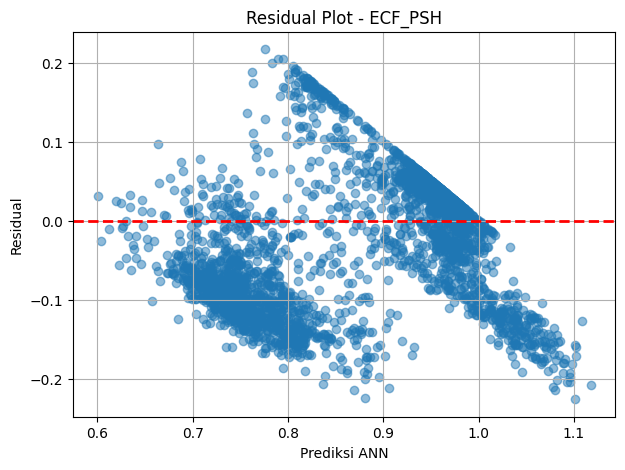

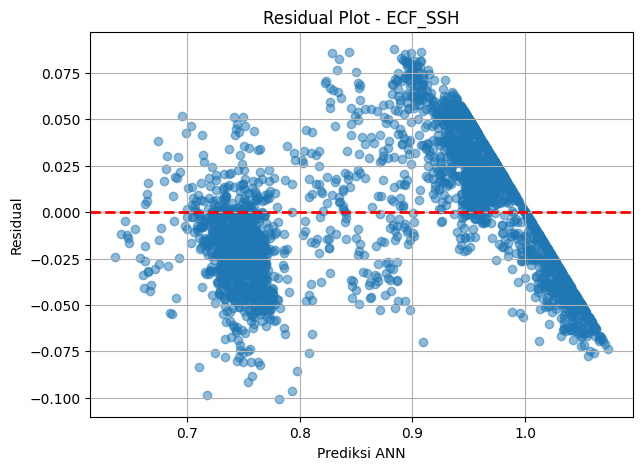

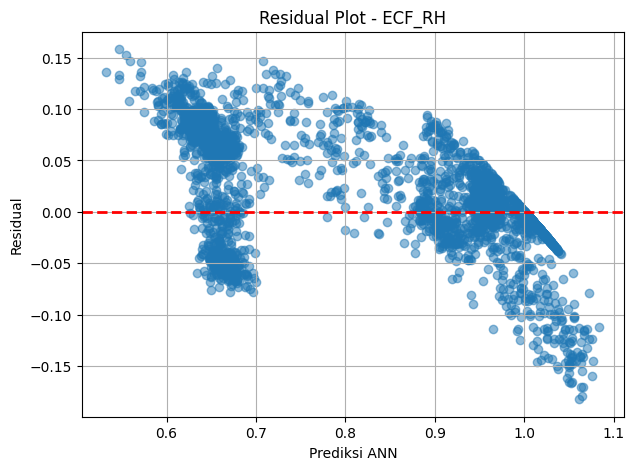

In [10]:
import matplotlib.pyplot as plt

residual = y_test.copy()

for col in targets:
    residual[col] = y_test[col] - y_pred[col]
print(residual.head())

for col in targets:
    plt.figure(figsize=(7,5))
    plt.scatter(
        y_pred[col],
        residual[col],
        alpha=0.5
    )
    plt.axhline(
        y=0,
        color='red',
        linestyle='--',
        linewidth=2
    )
    plt.xlabel("Prediksi ANN")
    plt.ylabel("Residual")
    plt.title(f"Residual Plot - {col}")
    plt.grid(True)
    plt.show()



**10. Test Model**

In [13]:
import pandas as pd
import numpy as np

# ==========================================================
# 1. FUNGSI TINGKAT FOULING, WARNA & REKOMENDASI TINDAKAN
# ==========================================================
def analisa_fouling_dan_rekomendasi(ecf):
    """
    Menentukan kategori fouling, indikator warna, dan rekomendasi operasional.
    """
    if ecf >= 0.90:
        status = 'Clean'
        warna = '🟢'
        rekomendasi = 'Operasi normal. Tidak perlu tindakan.'
    elif ecf >= 0.80:
        status = 'Light Fouling'
        warna = '🔵'
        rekomendasi = 'Kondisi wajar. Lakukan pemantauan rutin.'
    elif ecf >= 0.70:
        status = 'Moderate Fouling'
        warna = '🟠'
        rekomendasi = 'Persiapkan jadwal Soot Blowing.'
    else:
        status = 'Heavy Fouling'
        warna = '🔴'
        rekomendasi = '⚠️ SEGERA SOOT BLOWING! Efisiensi turun signifikan.'

    return status, warna, rekomendasi


# ==========================================================
# 2. AMBIL 1 BARIS DATA DARI EXCEL (Contoh: Index Ke-0)
# ==========================================================
index_pilihan = 8789  # Ganti indeks untuk mencoba sampel baris data lain

# Ambil sampel 1 baris
sampel_X = df_clean[features].iloc[[index_pilihan]]
sampel_y_aktual = df_clean[targets].iloc[index_pilihan]

# Standardisasi input X menggunakan scaler
sampel_X_scaled = scaler.transform(sampel_X) # Corrected from scaler_X to scaler


# ==========================================================
# 3. PREDIKSI, EVALUASI ERROR & REKOMENDASI OPERASIONAL
# ==========================================================
print("=" * 110)
print(f"DIAGNOSTIK FOULING & REKOMENDASI OPERASIONAL BOILER (BARIS EXCEL INDEKS KE-{index_pilihan})")
print("=" * 110)

# Displays Data Parameter Input
print("\n[ Parameter Input Sensor ]")
for col in features:
    print(f"• {col[:38]:<38} : {sampel_X[col].values[0]:.2f}")

print("\n" + "-" * 110)
print(f"{'TARGET':<8} | {'PREDIKSI':<9} | {'AKTUAL':<9} | {'ERROR (%)':<9} | {'STATUS FOULING':<18} | {'REKOMENDASI TINDAKAN':<45}")
print("-" * 110)

perlu_sootblowing_urgent = False

# Perform a single prediction for all targets using the trained model
all_targets_pred = model.predict(sampel_X_scaled)

for idx, col in enumerate(targets):
    # Access the predicted ECF value for the current target
    pred_ecf = all_targets_pred[0][idx] # model.predict returns a 2D array, so access the first row

    # Nilai Aktual & Hitung Error (%)
    aktual_ecf = sampel_y_aktual[col]
    abs_error = abs(pred_ecf - aktual_ecf)
    pct_error = (abs_error / abs(aktual_ecf)) * 100

    # Kategori Fouling & Rekomendasi
    status_fouling, warna, rekomendasi = analisa_fouling_dan_rekomendasi(pred_ecf)
    status_tampil = f"{warna} {status_fouling}"

    # Cek flag sootblowing
    if pred_ecf < 0.70:
        perlu_sootblowing_urgent = True

    # Display Output dalam format tabel
    print(f"{col:<8} | {pred_ecf:<9.4f} | {aktual_ecf:<9.4f} | {pct_error:<8.2f}% | {status_tampil:<18} | {rekomendasi:<45}")

print("=" * 110)

# Banner Peringatan Utama jika ada komponen yang butuh Soot Blowing
if perlu_sootblowing_urgent:
    print("\n🚨 [PERINGATAN OPERATOR]: Ditemukan penumpukan jelutong/jelutuh berat (Heavy Fouling). Rekomendasi: Jalankan soot blower pada area terkait segera!")

DIAGNOSTIK FOULING & REKOMENDASI OPERASIONAL BOILER (BARIS EXCEL INDEKS KE-8789)

[ Parameter Input Sensor ]
• 06IO00C00062-A - COAL FUEL SUPPLY RATE : 262.37
• 06DP6101M103-A - B TOTAL COMPT AIR FLO : 1999.75
• 06GG__AT001A00 - FURN OUT A FG O2 [%]  : 6.20
• 06SB__PT0000-X - MAIN STM PRESS MED SE : 124.79
• 06SJ__FT006A-X - ECON INL FW FLOW AVG  : 729.15
• 36EL__JT000G-B - UNIT MASTER GENERATED : 350.54

--------------------------------------------------------------------------------------------------------------
TARGET   | PREDIKSI  | AKTUAL    | ERROR (%) | STATUS FOULING     | REKOMENDASI TINDAKAN                         
--------------------------------------------------------------------------------------------------------------
ECF_PSH  | 0.7086    | 0.7167    | 1.13    % | 🟠 Moderate Fouling | Persiapkan jadwal Soot Blowing.              
ECF_SSH  | 0.7832    | 0.7858    | 0.34    % | 🟠 Moderate Fouling | Persiapkan jadwal Soot Blowing.              
ECF_RH   | 0.6743    | 0.66

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# ==========================================================
# 1. DEFINISI FITUR & TARGET
# ==========================================================
features = [
    '06IO00C00062-A - COAL FUEL SUPPLY RATE [t/h]',
    '06DP6101M103-A - B TOTAL COMPT AIR FLOW [t/h]',
    '06GG__AT001A00 - FURN OUT A FG O2 [%]',
    '06SB__PT0000-X - MAIN STM PRESS MED SEL XMTR [kg/cm2]',
    '06SJ__FT006A-X - ECON INL FW FLOW AVG SEL XMTR [t/h]',
    '36EL__JT000G-B - UNIT MASTER GENERATED MW []'
]

targets = [
    'ECF_PSH',
    'ECF_SSH',
    'ECF_RH'
]

# ==========================================================
# 2. LOGIKA UTAMA MONITORING & REKOMENDASI SOOT BLOWING
# ==========================================================
def analisa_fouling_dan_rekomendasi(ecf):
    if ecf >= 0.90:
        return 'Clean', '🟢', 'Operasi normal. Tidak perlu tindakan.'
    elif ecf >= 0.80:
        return 'Light Fouling', '🔵', 'Kondisi wajar. Lakukan pemantauan rutin.'
    elif ecf >= 0.70:
        return 'Moderate Fouling', '🟠', 'Persiapkan jadwal Soot Blowing.'
    else:
        return 'Heavy Fouling', '🔴', '⚠️ SEGERA SOOT BLOWING! Efisiensi turun signifikan.'

def prediksi_gui(coal_flow, air_flow, fg_o2, steam_press, fw_flow, generator_mw):
    input_df = pd.DataFrame([[coal_flow, air_flow, fg_o2, steam_press, fw_flow, generator_mw]], columns=features)
    input_scaled = scaler.transform(input_df)

    hasil_tabel = []
    perlu_sootblowing_urgent = False

    all_targets_pred = model.predict(input_scaled)

    for idx, col in enumerate(targets):
        pred_ecf = all_targets_pred[0][idx]
        status, warna, rekomendasi = analisa_fouling_dan_rekomendasi(pred_ecf)

        if pred_ecf < 0.70:
            perlu_sootblowing_urgent = True

        hasil_tabel.append([col, f"{pred_ecf:.4f}", f"{warna} {status}", rekomendasi])

    df_hasil = pd.DataFrame(hasil_tabel, columns=["Area Heat Exchanger", "Nilai ECF Prediksi", "Status Fouling", "Rekomendasi Tindakan"])

    if perlu_sootblowing_urgent:
        banner = "🚨 WARNING OPERATOR: Ditemukan Heavy Fouling pada komponen boiler! Rekomendasi: Lakukan SOOT BLOWING SEGERA!"
    else:
        banner = "✅ STATUS NORMAL: Seluruh komponen boiler dalam batas operasi aman."

    return banner, df_hasil

# Default values dari data
default_vals = df_clean[features].mean().to_dict()

# ==========================================================
# 3. CSS CUSTOM TEMA PLN INDONESIA POWER SERVICES
# ==========================================================
custom_css = """
/* Background utama & font */
.gradio-container {
    background: linear-gradient(135deg, #0A192F 0%, #00223E 100%) !important;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif !important;
    color: #FFFFFF !important;
}

/* Custom Header Bar PLN IP Style */
.pln-header {
    background: #002B49;
    border-bottom: 4px solid #00A8B5;
    padding: 15px 25px;
    border-radius: 12px;
    margin-bottom: 20px;
    display: flex;
    justify-content: space-between;
    align-items: center;
    box-shadow: 0 4px 20px rgba(0,0,0,0.3);
}

.pln-logo-text {
    font-size: 22px;
    font-weight: 800;
    color: #00A8B5;
    letter-spacing: 1px;
}

.pln-logo-sub {
    font-size: 13px;
    color: #FFCC00;
    font-weight: 600;
}

/* Panel Card Glassmorphism Style */
.panel-card {
    background: rgba(255, 255, 255, 0.05) !important;
    backdrop-filter: blur(10px);
    border: 1px solid rgba(0, 168, 181, 0.2) !important;
    border-radius: 12px !important;
    padding: 15px !important;
}

/* Styling Input Label & Box */
label span {
    color: #00A8B5 !important;
    font-weight: 600 !important;
}

input {
    background-color: #0B2545 !important;
    color: #FFFFFF !important;
    border: 1px solid #00A8B5 !important;
    border-radius: 8px !important;
}

/* Button Styling khas PLN IP (Tosca Gradient) */
.btn-pln {
    background: linear-gradient(90deg, #00A8B5 0%, #007788 100%) !important;
    color: #FFFFFF !important;
    font-weight: bold !important;
    font-size: 16px !important;
    border: none !important;
    border-radius: 8px !important;
    box-shadow: 0 4px 15px rgba(0, 168, 181, 0.4) !important;
    transition: all 0.3s ease !important;
}

.btn-pln:hover {
    background: linear-gradient(90deg, #00C4D4 0%, #00A8B5 100%) !important;
    transform: translateY(-2px);
}

/* Table Styling */
.dataframe {
    background-color: #0A192F !important;
    color: #FFFFFF !important;
    border-radius: 8px !important;
}
"""

# ==========================================================
# 4. ANTARMUKA GRADIO BLOCKS
# ==========================================================
with gr.Blocks(css=custom_css, title="PLN IP Services - Boiler ECF System") as demo:

    # Navbar Header
    gr.HTML(
        """
        <div class="pln-header">
            <div>
                <div class="pln-logo-text">⚡ PLN INDONESIA POWER SERVICES</div>
                <div class="pln-logo-sub">Solusi Energi Terintegrasi | Intelligent Boiler Diagnostics</div>
            </div>
            <div style="text-align: right; font-size: 12px; color: #E0E0E0;">
                <b>Unit Performance Monitoring</b><br>
                <span>Real-Time ECF & Soot Blowing Analytics</span>
            </div>
        </div>
        """
    )

    with gr.Row():
        # Kolom Kiri: Parameter Input Sensor
        with gr.Column(scale=1, elem_classes=["panel-card"]):
            gr.Markdown("### 🎛️ Input Parameter Sensor Real-Time")
            coal_flow = gr.Number(label=features[0], value=round(default_vals[features[0]], 2))
            air_flow = gr.Number(label=features[1], value=round(default_vals[features[1]], 2))
            fg_o2 = gr.Number(label=features[2], value=round(default_vals[features[2]], 2))
            steam_press = gr.Number(label=features[3], value=round(default_vals[features[3]], 2))
            fw_flow = gr.Number(label=features[4], value=round(default_vals[features[4]], 2))
            generator_mw = gr.Number(label=features[5], value=round(default_vals[features[5]], 2))

            btn_predict = gr.Button("🔍 ANALISIS TINGKAT FOULING", elem_classes=["btn-pln"])

        # Kolom Kanan: Output Diagnostic Dashboard
        with gr.Column(scale=2, elem_classes=["panel-card"]):
            gr.Markdown("### 📊 Dashboard Diagnostik & Status Operasional")
            banner_output = gr.Textbox(label="Status Sistem Utama", interactive=False)
            tabel_output = gr.Dataframe(label="Rincian Efisiensi Kebersihan (ECF) & Rekomendasi Action", interactive=False)

    # Footer
    gr.HTML(
        """
        <div style="text-align: center; margin-top: 25px; color: #8892B0; font-size: 12px;">
            © 2026 PLN Indonesia Power Services — Advanced Machine Learning Boiler Performance System
        </div>
        """
    )

    # Event Listener
    btn_predict.click(
        fn=prediksi_gui,
        inputs=[coal_flow, air_flow, fg_o2, steam_press, fw_flow, generator_mw],
        outputs=[banner_output, tabel_output]
    )

# Jalankan Dashboard
demo.launch(share=True, debug=True)

/tmp/ipykernel_1718/2707519965.py:155: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, title="PLN IP Services - Boiler ECF System") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://cf85268cf36b376a19.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


                                              Variabel      n     Avg. Std Dev Minimum Q1 (25%)  Median Q3 (75%) Maksimum
     06AE__TE0401-X - PSH II INL TEMP S A SEL XMTR [C] 14.400  351,885  11,794  330,04   339,26  356,13   360,92   380,35
               06AE__TE040800 - PSH 2 STM TEMP [DEG C] 14.400  432,462   8,976  407,43   426,72  433,87   438,97   457,34
             06AE__TE0409-X - SSH INL TEMP S A SEL [C] 14.400  353,965  10,911  330,09   343,15  355,87   363,49   378,42
06AE__TE392A00 - FEEDWATER TO ECON OUT TEMP SI [DEG C] 14.400  245,449   6,277  227,53   241,33  247,05   250,23   260,47
               06AL__TE006A-X - PA A TEMP XMTR SEL [C] 14.400  231,149  13,532  189,88   221,82  231,81   241,84   258,87
         06DP6101M103-A - B TOTAL COMPT AIR FLOW [t/h] 14.400 2138,418 215,012 1597,89  1953,37 2221,24  2334,39  2533,06
                 06GG__AT001A00 - FURN OUT A FG O2 [%] 14.400    5,323   0,841    3,21     4,80    5,34     5,88     7,60
          06IO00C00062-A

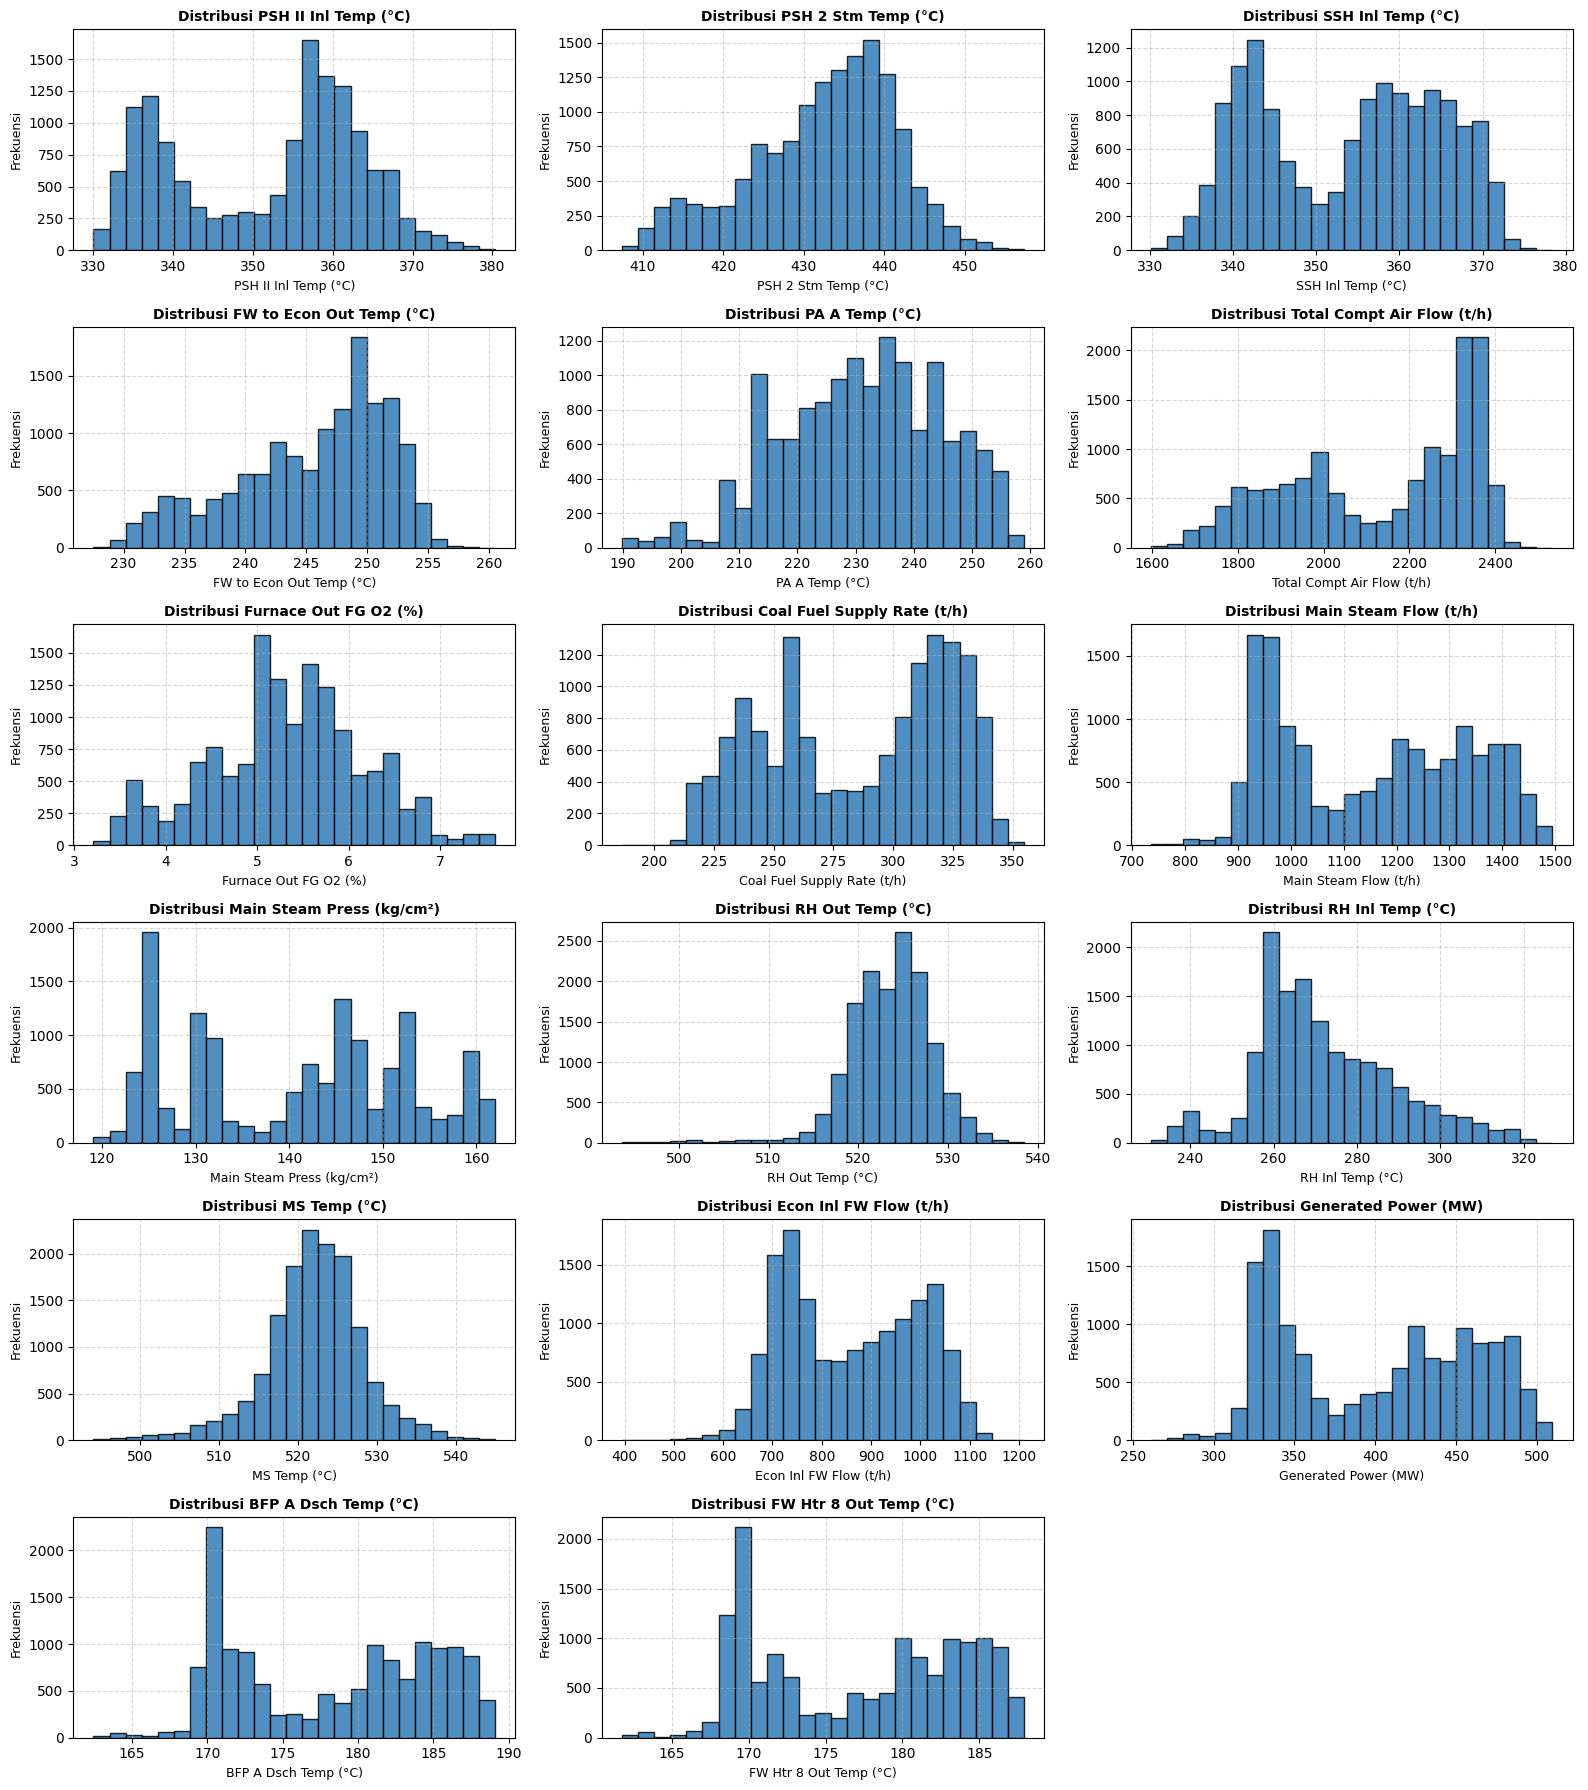

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
file_path = '/content/PKL 2607.xlsx'
df = pd.read_excel(file_path)

# Hapus kolom penampung kosong 'Unnamed'
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Filter hanya kolom numerik (abaikan kolom Time)
kolom_numerik = [col for col in df.columns if col != 'Time']

# 2. Fungsi Perhitungan Statistik Deskriptif
def hitung_statistik_excel(data, kolom_list):
    ringkasan = []
    for col in kolom_list:
        s = data[col].dropna()
        ringkasan.append({
            'Variabel': col,
            'n': f"{len(s):,}".replace(',', '.'),
            'Avg.': f"{s.mean():.3f}".replace('.', ','),
            'Std Dev': f"{s.std():.3f}".replace('.', ','),
            'Minimum': f"{s.min():.2f}".replace('.', ','),
            'Q1 (25%)': f"{s.quantile(0.25):.2f}".replace('.', ','),
            'Median': f"{s.median():.2f}".replace('.', ','),
            'Q3 (75%)': f"{s.quantile(0.75):.2f}".replace('.', ','),
            'Maksimum': f"{s.max():.2f}".replace('.', ',')
        })
    return pd.DataFrame(ringkasan)

# Tampilkan Tabel Statistik
tabel_statistik = hitung_statistik_excel(df, kolom_numerik)
print(tabel_statistik.to_string(index=False))

# 3. Visualisasi Histogram
# Pemetaan Nama Singkat untuk Judul Grafik
nama_singkat = {
    '06AE__TE0401-X - PSH II INL TEMP S A SEL XMTR [C]': 'PSH II Inl Temp (°C)',
    '06AE__TE040800 - PSH 2 STM TEMP [DEG C]': 'PSH 2 Stm Temp (°C)',
    '06AE__TE0409-X - SSH INL TEMP S A SEL [C]': 'SSH Inl Temp (°C)',
    '06AE__TE392A00 - FEEDWATER TO ECON OUT TEMP SI [DEG C]': 'FW to Econ Out Temp (°C)',
    '06AL__TE006A-X - PA A TEMP XMTR SEL [C]': 'PA A Temp (°C)',
    '06DP6101M103-A - B TOTAL COMPT AIR FLOW [t/h]': 'Total Compt Air Flow (t/h)',
    '06GG__AT001A00 - FURN OUT A FG O2 [%]': 'Furnace Out FG O2 (%)',
    '06IO00C00062-A - COAL FUEL SUPPLY RATE [t/h]': 'Coal Fuel Supply Rate (t/h)',
    '06SB__FT000X-X - MAIN STEAM FLOW [t/h]': 'Main Steam Flow (t/h)',
    '06SB__PT0000-X - MAIN STM PRESS MED SEL XMTR [kg/cm2]': 'Main Steam Press (kg/cm²)',
    '06SB__TE000X-X - RH OUT TEMP SEL XMTR [C]': 'RH Out Temp (°C)',
    '06SB__TE0073-X - RH INL TEMP S A SEL XMTR [C]': 'RH Inl Temp (°C)',
    '06SB__TE0171-X - MS TEMP SEL XMTR [C]': 'MS Temp (°C)',
    '06SJ__FT006A-X - ECON INL FW FLOW AVG SEL XMTR [t/h]': 'Econ Inl FW Flow (t/h)',
    '36EL__JT000G-B - UNIT MASTER GENERATED MW []': 'Generated Power (MW)',
    '36SJ__TE0002 - BFP A DSCH TEMP [DEG C]': 'BFP A Dsch Temp (°C)',
    '36SJ__TE0011 - FW HTR 8 OUT TEMP [DEG C]': 'FW Htr 8 Out Temp (°C)'
}

fig, axes = plt.subplots(6, 3, figsize=(16, 18))
axes_flat = axes.flatten()

for i, col in enumerate(kolom_numerik):
    ax = axes_flat[i]
    ax.hist(df[col].dropna(), bins=25, color='#337ab7', edgecolor='black', alpha=0.85)

    label = nama_singkat.get(col, col)
    ax.set_title(f'Distribusi {label}', fontsize=10, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

# Hapus subplot yang tersisa jika ada
for j in range(len(kolom_numerik), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.savefig('pkl_2607_distributions.png', dpi=300)
plt.show()